In [1]:
import os
import pandas as pd
from skbio import OrdinationResults
from joint_rpca_functions import subject_boxplot
from joint_rpca_output_preprocessing import misame_meta_add_cols

%matplotlib inline

In [2]:
imic_dir_path = os.path.expanduser('~/NYU Langone Health Dropbox/Bianca Cordazzo Vargas/Shenhav_Lab/IMiC')
misame_meta_path = f'{imic_dir_path}/Data/MISAME/metadata/misame_processed_metadata.tsv'
joint_rpca_out_path = f'{imic_dir_path}/Code/Joint-RPCA/output/all_tps'
figure_path = f'{imic_dir_path}/Figures/Joint-RPCA'

## Figure S2

### MISAME

In [3]:
#metadata
misame_metadata = pd.read_csv(misame_meta_path, sep='\t', index_col=0)
misame_metadata = misame_meta_add_cols(misame_metadata)

In [4]:
#load Joint-RPCA results
ord_misame = OrdinationResults.read(f'{joint_rpca_out_path}/misame_ord_with_untarg_sapient_final.txt')
ord_misame_samples = ord_misame.samples.rename(columns={0:'PC1', 1:'PC2', 2:'PC3', 3:'PC4'})

#create dict with proportione explained
prop_explained_misame = {}
for i, prop in enumerate(ord_misame.proportion_explained):
    prop_explained_misame["PC" + str(i+1)] = round(prop*100, 2)
print("With sapient subset:", prop_explained_misame)

#create df for plotting
ord_misame_plt_ = pd.concat([ord_misame_samples, misame_metadata], axis=1, sort=True)
ord_misame_plt_['BEP'] = ord_misame_plt_['BEP'].astype('category')

With sapient subset: {'PC1': 50.83, 'PC2': 49.04, 'PC3': 0.12}


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:5.773e-05 U_stat=2.087e+04


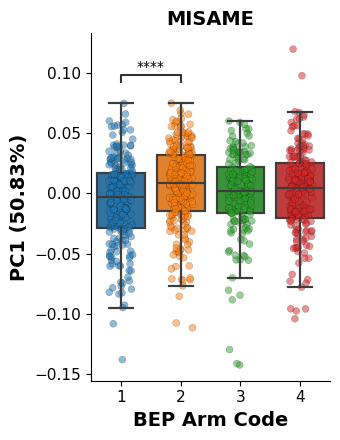

In [5]:
phenotype = 'ARMCD'
order_ = [1, 2, 3, 4]
pc='PC1'

subject_boxplot(plot_df=ord_misame_plt_, x_=phenotype, y_=pc, order_=order_, 
                palette_=None,
                prop_explained_=prop_explained_misame,
                xlabel_='BEP Arm Code', title_='MISAME', save_fig=False, 
                save_path=f'{figure_path}/MISAME_BEP_boxplot_{pc}.pdf')